In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import scipy
from scipy.optimize import differential_evolution, minimize
import warnings
from pymoo.util.ref_dirs import get_reference_directions
warnings.filterwarnings("ignore")



In [2]:
def obj_fun(x):
    # Coefficients for the two objective polynomials
    p1 = np.array([0.0009, 0.0004, -0.0103, -0.0403, -0.0236])
    p2 = np.array([0.0014, 0.0004, -0.0376, -0.0010, 0.0902])
    f1 = np.polyval(p1, x)
    f2 = np.polyval(p2, x)
    F = np.hstack([f1, f2])
    return F

def TCH(w, f, z):
    return np.max(w * np.abs(f - z))

def EI_opt_MC(x, gaussian_process_1, gaussian_process_2, g_best, w, z):
    x = x.reshape(1, -1)
    mu1, sigma1 = gaussian_process_1.predict(x, return_std=True)
    mu2, sigma2 = gaussian_process_2.predict(x, return_std=True)
    
    mu = np.array([mu1, mu2]).reshape(-1)
    sigma = np.array([sigma1, sigma2]).flatten()
    cov_matrix = np.diag(sigma**2)
    
    # Monte Carlo Sampling
    samples = np.random.multivariate_normal(mu, cov_matrix, 1000)
    I = np.zeros(len(samples))
    for j in range(len(samples)):
        ss = samples[j, :]
        g = TCH(w, ss, z)
        I[j] = np.max(g_best - g, 0)
        
    EI = np.mean(I)
    return -EI

def phi(x):
    return scipy.stats.norm.pdf(x)

def Phi(x):
    return scipy.stats.norm.cdf(x)

def EI(x,gaussian_process,g_best):
    x = x.reshape(1,-1)
    mu,sigma = gaussian_process.predict(x,return_std=True)
    s = (g_best - mu)/sigma
    EI = -(sigma*s * Phi(s) + sigma*phi(s))
    EI = EI.reshape(-1)
    return -EI

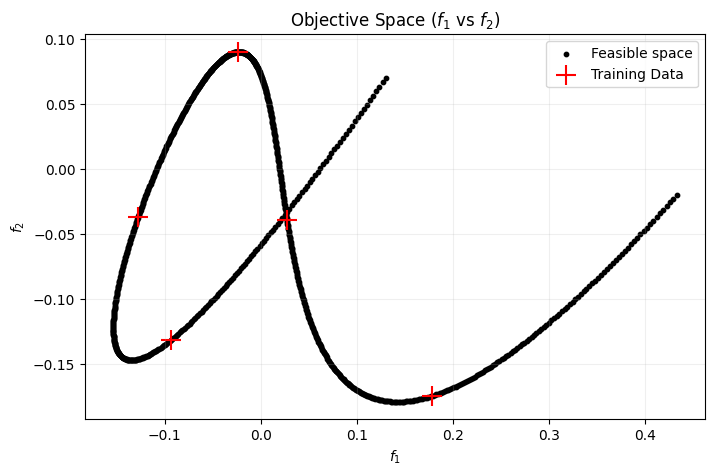

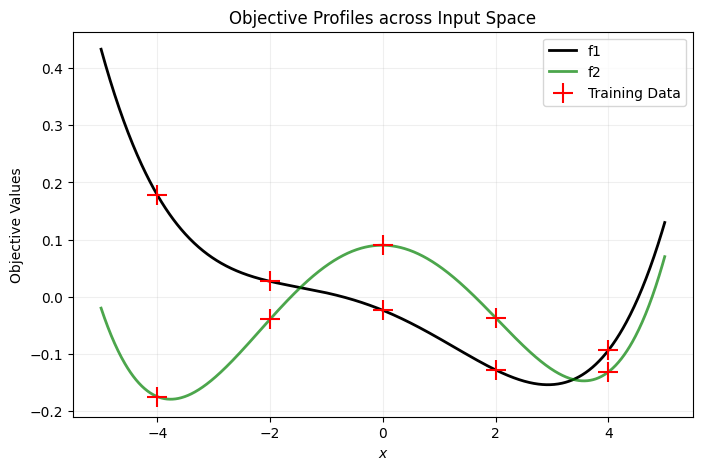

In [6]:
# Generate simulated text file data if it doesn't exist locally
try:
    X = np.loadtxt('x_train_demo.txt')
except IOError:
    # Fallback to dummy training data if the file is missing
    X = np.array([-4.0, -2.0, 0.0, 2.0, 4.0])
    np.savetxt('x_train_demo.txt', X)

if X.ndim == 1:
    X = X.reshape(-1, 1)

n_initial = X.shape[0]
f = np.zeros((X.shape[0], 2))
for i in range(len(X)):
    f[i, :] = obj_fun(X[i])

# FIXED: Re-shaped to (1000, 1) so it indexes correctly over iterations
x_plot = np.linspace(-5, 5, 1000).reshape(-1, 1)
y_plot = np.zeros((x_plot.shape[0], 2))
for i in range(len(x_plot)):
    y_plot[i, :] = obj_fun(x_plot[i])

# --- Plot the Objective Trade-off Space ---
plt.figure(figsize=(8, 5))
plt.scatter(y_plot[:, 0], y_plot[:, 1], color='k', label='Feasible space', s=10)
plt.scatter(f[:, 0], f[:, 1], 200, marker='+', color='red', label='Training Data')
plt.title("Objective Space ($f_1$ vs $f_2$)")
plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# --- Plot Objectives across X-domain ---
plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot[:, 0], color='k', label='f1', lw=2)
plt.plot(x_plot, y_plot[:, 1], color='g', label='f2', alpha=0.7, lw=2)
plt.scatter(X, f[:, 0], 200, marker='+', color='red', label='Training Data', zorder=5)
plt.scatter(X, f[:, 1], 200, marker='+', color='red', zorder=5)
plt.title("Objective Profiles across Input Space")
plt.xlabel("$x$")
plt.ylabel("Objective Values")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Calculate Reference Ideal & Nadir Points
z_ideal = np.min(y_plot, axis=0)
z_nadir = np.max(y_plot, axis=0)

# Reference vector setup
weight_vectors = 1 / (z_nadir - z_ideal) 

g_plot = np.zeros(len(y_plot))
for i in range(len(y_plot)):
    g_plot[i] = TCH(weight_vectors, y_plot[i, :], z_ideal)

f_train = f
w = weight_vectors
g = np.zeros(len(f_train))
for i in range(len(f)):
    g[i] = TCH(w, f_train[i, :], z_ideal)

g_best = np.min(g)


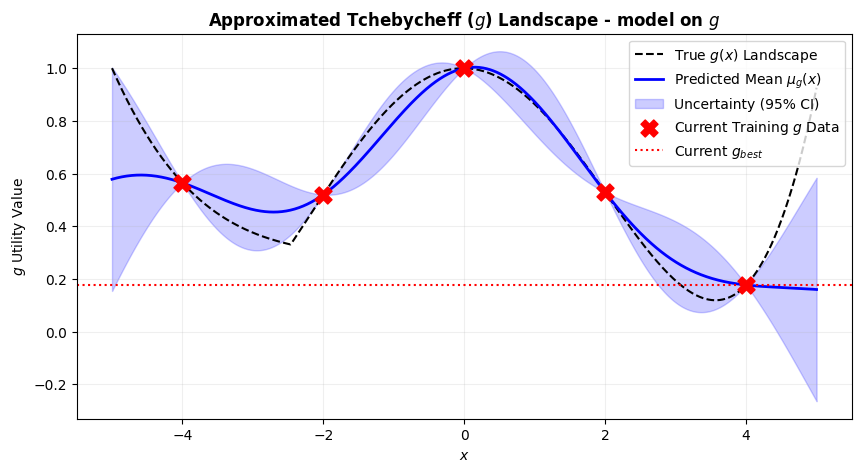

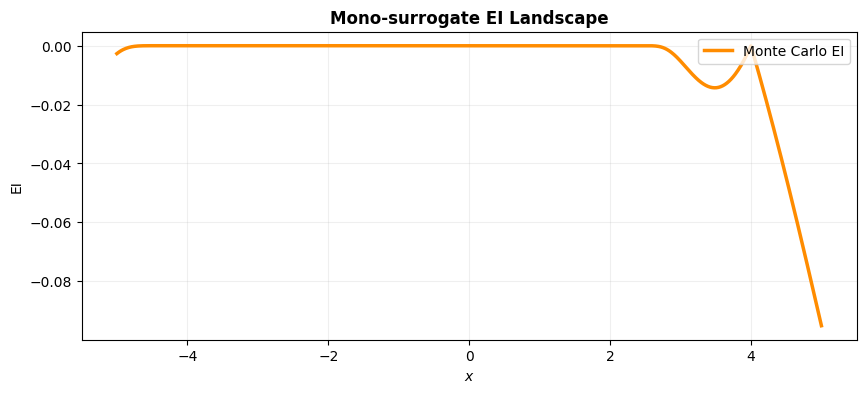

In [10]:
# Fit GPs on g
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process_g = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process_g.fit(X, g)

# =====================================================================
# COMPLETION: Monte Carlo Landscape Prediction Loop
# =====================================================================
ei_values_g = np.zeros(len(x_plot))
g_mean_est_g = np.zeros(len(x_plot))
g_std_est_g = np.zeros(len(x_plot))

# Sample size for Monte Carlo estimation at each grid point

for i in range(0, len(x_plot)):
    mu_g, std_g = gaussian_process_g.predict(x_plot[i].reshape(1, -1), return_std=True)

        
    # Store empirical mean and standard deviation of the scalarized surface
    g_mean_est_g[i] = mu_g
    g_std_est_g[i] = std_g
    
    # 3. Estimate EI values using the pre-defined MC acquisition tracker
    # We strip the negative sign since EI_opt_MC returns minimization utility (-EI)
    ei_values_g[i] = -EI(x_plot[i], gaussian_process_g, g_best)

# =====================================================================
# COMPLETION: Plotting the Results
# =====================================================================

# Plot 1: Estimated Tchebycheff (g) Landscape with Uncertainty Bounds
plt.figure(figsize=(10, 5))
plt.plot(x_plot, g_plot, 'k--', label='True $g(x)$ Landscape', lw=1.5)
plt.plot(x_plot, g_mean_est_g, 'b-', label='Predicted Mean $\mu_g(x)$', lw=2)
plt.fill_between(
    x_plot.ravel(),
    g_mean_est_g - 1.96 * g_std_est_g,
    g_mean_est_g + 1.96 * g_std_est_g,
    color='blue', alpha=0.2, label='Uncertainty (95% CI)'
)
plt.scatter(X, g, 150, marker='X', color='red', label='Current Training $g$ Data', zorder=5)
plt.axhline(g_best, color='red', linestyle=':', label='Current $g_{best}$')
plt.title("Approximated Tchebycheff ($g$) Landscape - model on $g$", weight='bold')
plt.xlabel("$x$")
plt.ylabel("$g$ Utility Value")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

# Plot 2: Monte Carlo Expected Improvement Landscape
plt.figure(figsize=(10, 4))
plt.plot(x_plot, ei_values_g, color='darkorange', lw=2.5, label='Monte Carlo EI')
plt.title("Mono-surrogate EI Landscape", weight='bold')
plt.xlabel("$x$")
plt.ylabel("EI")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# Fit GPs on individual objectives

 # Aligning weight assignment with scalarization goals


kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process_1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process_2 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
    
gaussian_process_1.fit(X, f_train[:, 0])
gaussian_process_2.fit(X, f_train[:, 1])


# =====================================================================
# COMPLETION: Monte Carlo Landscape Prediction Loop
# =====================================================================
ei_values = np.zeros(len(x_plot))
g_mean_est = np.zeros(len(x_plot))
g_std_est = np.zeros(len(x_plot))

# Sample size for Monte Carlo estimation at each grid point
mc_samples_count = 500 

for i in range(0, len(x_plot)):
    mu1, std1 = gaussian_process_1.predict(x_plot[i].reshape(1, -1), return_std=True)
    mu2, std2 = gaussian_process_2.predict(x_plot[i].reshape(1, -1), return_std=True)
    
    mean_vector = np.array([mu1[0], mu2[0]])
    cov_matrix = np.diag([std1[0]**2, std2[0]**2])
    
    # 1. Sample from the joint distribution
    obj_samples = np.random.multivariate_normal(mean_vector, cov_matrix, mc_samples_count)
    
    # 2. Estimate the scalarized g-values for each sample
    g_samples = np.zeros(mc_samples_count)
    for j in range(mc_samples_count):
        g_samples[j] = TCH(w, obj_samples[j, :], z_ideal)
        
    # Store empirical mean and standard deviation of the scalarized surface
    g_mean_est[i] = np.mean(g_samples)
    g_std_est[i] = np.std(g_samples)
    
    # 3. Estimate EI values using the pre-defined MC acquisition tracker
    # We strip the negative sign since EI_opt_MC returns minimization utility (-EI)
    ei_values[i] = -EI_opt_MC(x_plot[i], gaussian_process_1, gaussian_process_2, g_best, w, z_ideal)

# =====================================================================
# COMPLETION: Plotting the Results
# =====================================================================

# Plot 1: Estimated Tchebycheff (g) Landscape with Uncertainty Bounds
plt.figure(figsize=(10, 5))
plt.plot(x_plot, g_plot, 'k--', label='True $g(x)$ Landscape', lw=1.5)
plt.plot(x_plot, g_mean_est, 'b-', label='Predicted Mean $\mu_g(x)$', lw=2)
plt.fill_between(
    x_plot.ravel(),
    g_mean_est - 1.96 * g_std_est,
    g_mean_est + 1.96 * g_std_est,
    color='blue', alpha=0.2, label='Uncertainty (95% CI)'
)
plt.scatter(X, g, 150, marker='X', color='red', label='Current Training $g$ Data', zorder=5)
plt.axhline(g_best, color='red', linestyle=':', label='Current $g_{best}$')
plt.title("Approximated Tchebycheff ($g$) Landscape - models on $f_1$ and $f_2$", weight='bold')
plt.xlabel("$x$")
plt.ylabel("$g$ Utility Value")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

# Plot 2: Monte Carlo Expected Improvement Landscape
plt.figure(figsize=(10, 4))
plt.plot(x_plot, ei_values, color='darkorange', lw=2.5, label='Monte Carlo EI')
plt.title("Multi-surrogate EI Landscape", weight='bold')
plt.xlabel("$x$")
plt.ylabel("EI")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()